#Fashin MNIST
Fashion Mnist는 옷, 바지 등 10가지 종류의 의류로 구성된 데이터입니다. 이 데이터는 (28, 28) 크기로 구성되어 있으며 Training Set 6만장, Test Set 1만장으로 총합 7만장으로 이루어져 있습니다. Keras에서 dataset을 import 할 수 있고, 처음 import 시 다운로드 하는 과정이 추가됩니다.

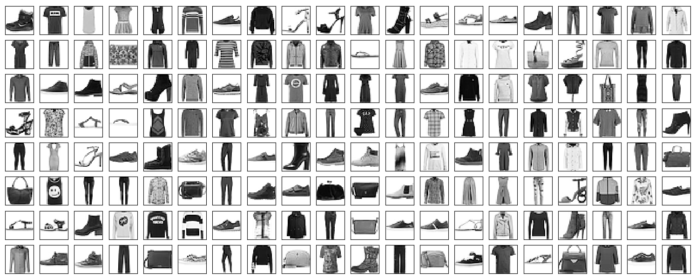


In [16]:
from tensorflow.keras import datasets, layers, models, utils
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train2d, y_train),(x_test2d, y_test) = datasets.fashion_mnist.load_data()

In [3]:
print(x_train2d.shape, y_train.shape)
print(x_test2d.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [4]:
items = {0:'T-shirt/top', 1:'Trouser', 2:'Pullover', 3:'Dress',
         4:'Coat', 5:'Sandal', 6:'Shirt', 7:'Sneaker',
         8:'Bag', 9:'Ankel boot'}

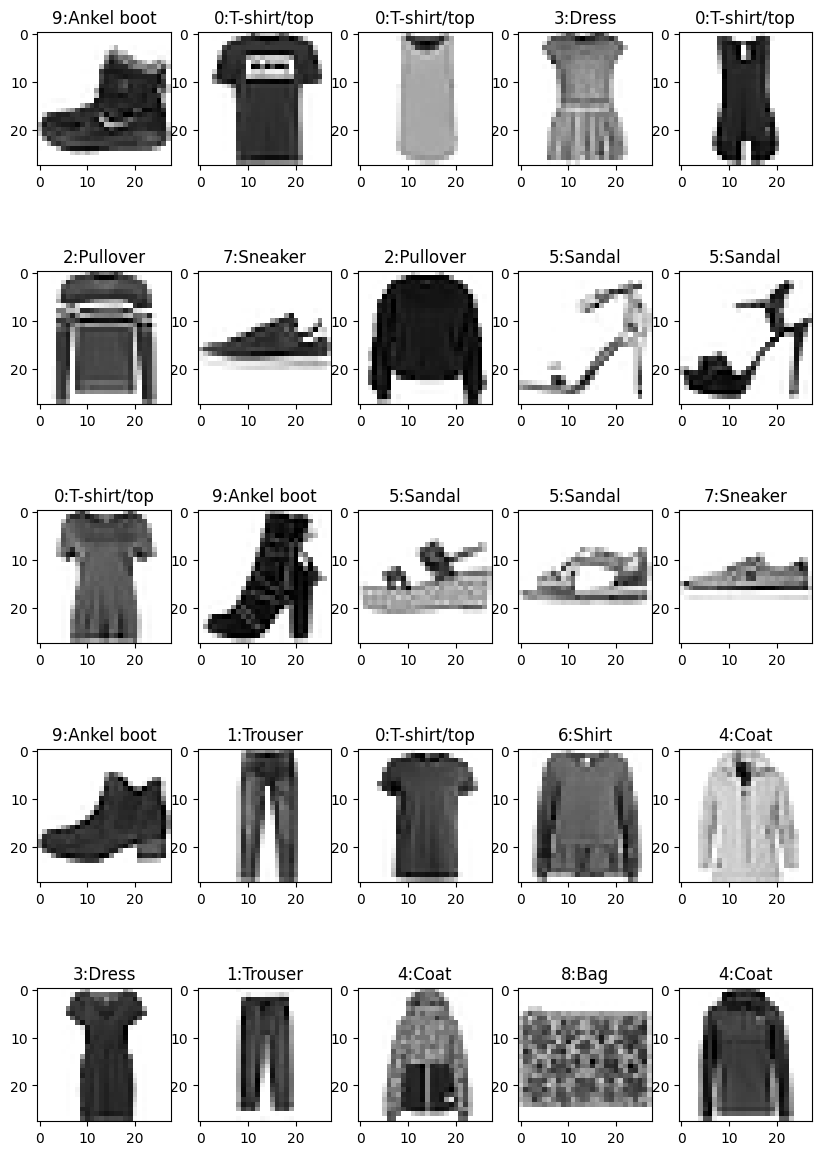

In [5]:
fig, axs = plt.subplots(5, 5, figsize=(10,15))
for i in range(5):
  for j in range(5):
    axs[i, j].set_title('{}:{}'.format(y_train[i*5+j], items[y_train[i*5+j]]))
    axs[i, j].imshow(x_train2d[i*5+j], cmap='gray_r')
plt.show()

In [6]:
x_train = x_train2d.reshape(-1, 28, 28, 1)
x_test = x_test2d.reshape(-1, 28, 28, 1)

In [7]:
x_train = x_train / 255
x_test = x_test / 255

#모델구성

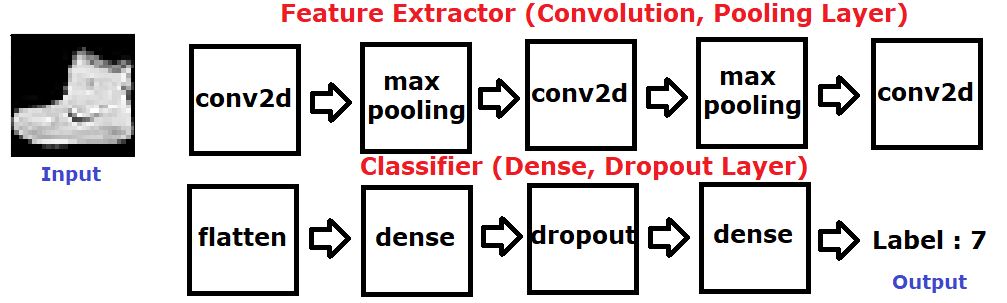

## Feature Extractor

In [8]:
model =models.Sequential()
model.add(layers.Conv2D(32, (3,3), padding='same',activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2),strides=2)) #일반적으로 strides는 커널 크기(2,2)와 동일하게 설정하여 겹치지 않도록 함
model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((2,2),strides=2))
model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(layers.Flatten()) #2차원 이상의 데이터를 1차원으로 변환하는 레이어
model.add(layers.Dense(128, activation='relu')) #128개의 뉴런을 가진 완전 연결층, 활성화 함수는 relu
model.add(layers.Dropout(0.3)) #과적합 방지 위해 Dropout 레이어 추가, 0.3는 30%의 뉴런을 무작위로 끔
model.add(layers.Dense(10, activation='softmax')) #10개의 뉴런을 가진 완전 연결층, 활성화 함수는 softmax, 출력층
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [10]:
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8279 - loss: 0.4812 - val_accuracy: 0.8855 - val_loss: 0.3062
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8895 - loss: 0.3032 - val_accuracy: 0.9033 - val_loss: 0.2680
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9072 - loss: 0.2554 - val_accuracy: 0.9076 - val_loss: 0.2537
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9192 - loss: 0.2225 - val_accuracy: 0.9143 - val_loss: 0.2288
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9289 - loss: 0.1931 - val_accuracy: 0.9179 - val_loss: 0.2208
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9363 - loss: 0.1707 - val_accuracy: 0.9204 - val_loss: 0.2250
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9446 - loss: 0.1497 - val_accuracy: 0.9249 - val_loss: 0.2281
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9509 - loss: 0.1302 -

### Classifier

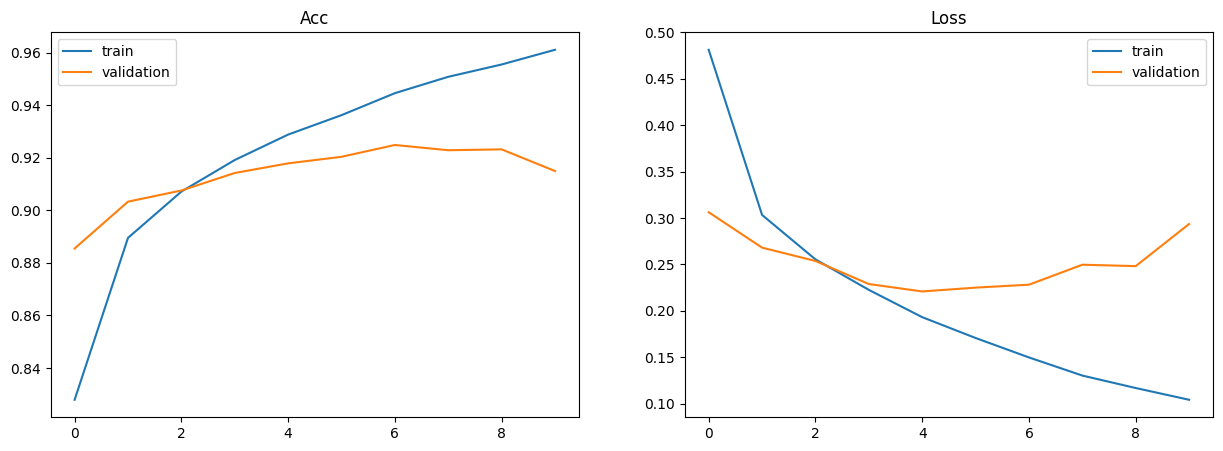

In [19]:
def plot_history(history):
    plt.figure(figsize=(15,5))

    plt.subplot(1,2,1)
    plt.plot(history['accuracy'])
    plt.plot(history['val_accuracy'])
    plt.legend(['train','validation'])
    plt.title('Acc')

    plt.subplot(1,2,2)
    plt.plot(history['loss'])
    plt.plot(history['val_loss'])
    plt.legend(['train','validation'])
    plt.title('Loss')

    plt.show()
plot_history(history.history)

# Drop out<br>
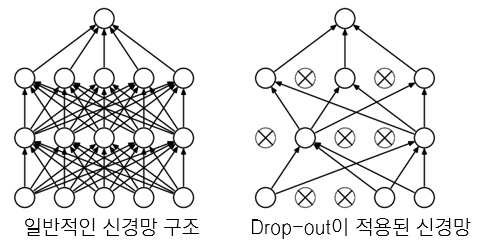

## BatchNormalization
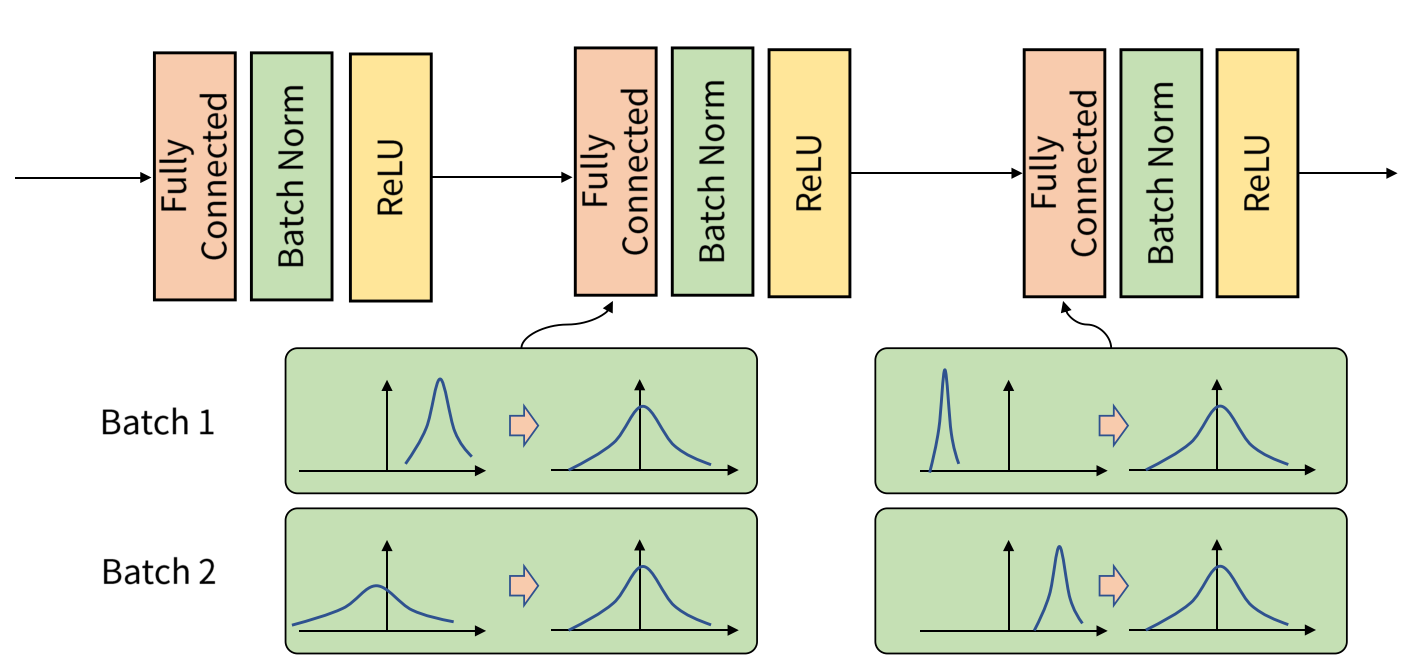

In [ ]:
model2 =models.Sequential()
model2.add(layers.Conv2D(32, (3,3), padding='same',activation='relu', input_shape=(28,28,1)))
model2.add(layers.BatchNormalization()) #배치 정규화 레이어 추가, 각 배치마다 입력을 정규화하여 학습 안정성과 속도 향상, 과적합 방지에도 도움
model2.add(layers.MaxPooling2D((2,2),strides=2)) #일반적으로 strides는 커널 크기(2,2)와 동일하게 설정하여 겹치지 않도록 함
model2.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model2.add(layers.BatchNormalization())
model2.add(layers.MaxPooling2D((2,2),strides=2))
model2.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model2.add(layers.Flatten()) #2차원 이상의 데이터를 1차원으로 변환하는 레이어
model2.add(layers.Dense(128, activation='relu')) #128개의 뉴런을 가진 완전 연결층, 활성화 함수는 relu
model2.add(layers.Dropout(0.3)) #과적합 방지 위해 Dropout 레이어 추가, 0.3는 30%의 뉴런을 무작위로 끔
model2.add(layers.Dense(10, activation='softmax')) #10개의 뉴런을 가진 완전 연결층, 활성화 함수는 softmax, 출력층
model2.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,290 (3.42 MB)

 Trainable params: 897,098 (3.42 MB)

 Non-trainable params: 192 (768.00 B)

In [26]:
model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [27]:
history = model2.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8514 - loss: 0.4259 - val_accuracy: 0.8782 - val_loss: 0.3299
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8967 - loss: 0.2832 - val_accuracy: 0.9051 - val_loss: 0.2651
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9119 - loss: 0.2435 - val_accuracy: 0.9096 - val_loss: 0.2690
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9206 - loss: 0.2169 - val_accuracy: 0.8925 - val_loss: 0.3189
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9297 - loss: 0.1930 - val_accuracy: 0.9172 - val_loss: 0.2208
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9364 - loss: 0.1701 - val_accuracy: 0.9151 - val_loss: 0.2435
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9421 - loss: 0.1540 - val_accuracy: 0.9193 - val_loss: 0.2451
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9450 - loss: 0.1458 -

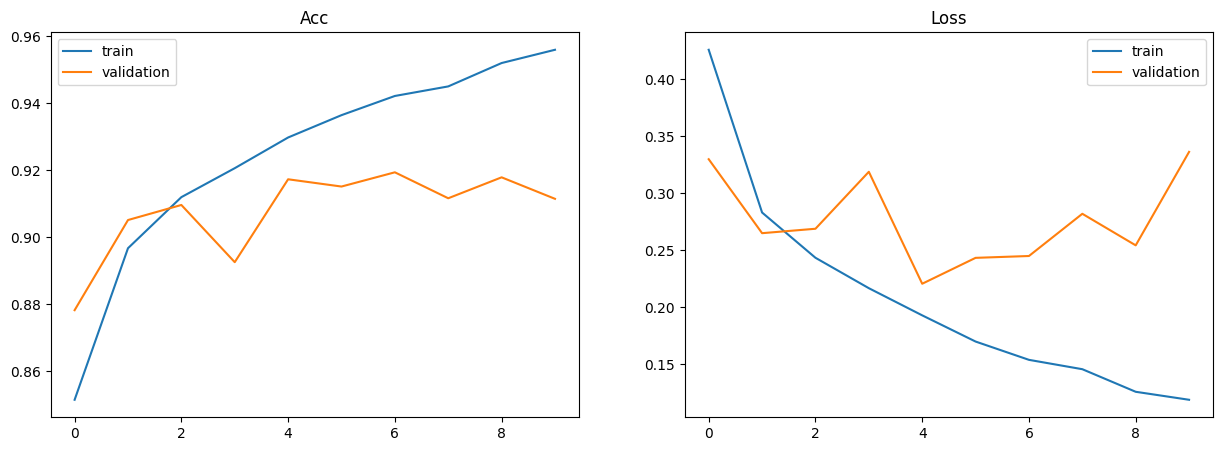

In [29]:
plot_history(history.history)

In [30]:
model2.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9044 - loss: 0.3816


[0.3815698027610779, 0.9043999910354614]

## Callback

callback = 학습 중간중간 자동으로 실행되는 도우미 기능

In [31]:
model3 =models.Sequential()
model3.add(layers.Conv2D(32, (3,3), padding='same',activation='relu', input_shape=(28,28,1)))
model3.add(layers.BatchNormalization()) #배치 정규화 레이어 추가, 각 배치마다 입력을 정규화하여 학습 안정성과 속도 향상, 과적합 방지에도 도움
model3.add(layers.MaxPooling2D((2,2),strides=2)) #일반적으로 strides는 커널 크기(2,2)와 동일하게 설정하여 겹치지 않도록 함
model3.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model3.add(layers.BatchNormalization())
model3.add(layers.MaxPooling2D((2,2),strides=2))
model3.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model3.add(layers.Flatten()) #2차원 이상의 데이터를 1차원으로 변환하는 레이어
model3.add(layers.Dense(128, activation='relu')) #128개의 뉴런을 가진 완전 연결층, 활성화 함수는 relu
model3.add(layers.Dropout(0.3)) #과적합 방지 위해 Dropout 레이어 추가, 0.3는 30%의 뉴런을 무작위로 끔
model3.add(layers.Dense(10, activation='softmax')) #10개의 뉴런을 가진 완전 연결층, 활성화 함수는 softmax, 출력층
model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,290 (3.42 MB)

 Trainable params: 897,098 (3.42 MB)

 Non-trainable params: 192 (768.00 B)

In [35]:
model3.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [36]:
checkpoint_cb=keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True) #모델 체크포인트 콜백 생성, "best_model.keras" 파일에 가장 성능이 좋은 모델 저장, save_best_only=True는 검증 성능이 향상될 때만 모델 저장
history = model3.fit(x_train, y_train, epochs=10, validation_split=0.2, callbacks=[checkpoint_cb]) #모델 학습, 체크포인트 콜백 추가하여 학습, 검증 데이터로 20% 사용, callback's'=리스트로 전달해달라는 뜻

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9586 - loss: 0.1141 - val_accuracy: 0.9180 - val_loss: 0.3376
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9612 - loss: 0.1059 - val_accuracy: 0.9201 - val_loss: 0.2615
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9654 - loss: 0.0912 - val_accuracy: 0.9122 - val_loss: 0.3136
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9678 - loss: 0.0879 - val_accuracy: 0.9210 - val_loss: 0.3373
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9698 - loss: 0.0810 - val_accuracy: 0.9210 - val_loss: 0.3824
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9739 - loss: 0.0719 - val_accuracy: 0.8782 - val_loss: 0.6341
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9728 - loss: 0.0728 - val_accuracy: 0.9246 - val_loss: 0.3909
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9756 - loss: 0.0643 

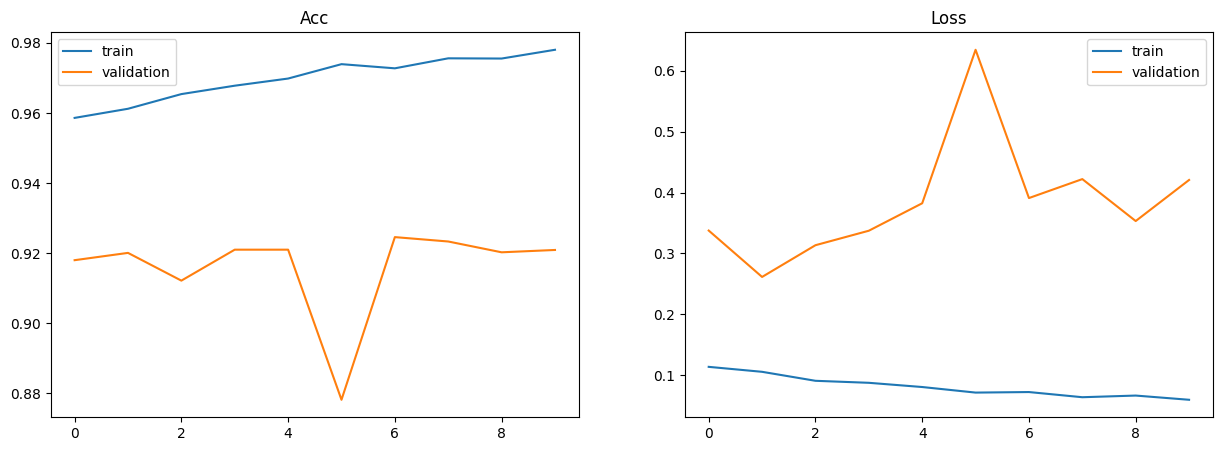

In [37]:
plot_history(history.history)

In [38]:
model4 =models.Sequential()
model4.add(layers.Conv2D(32, (3,3), padding='same',activation='relu', input_shape=(28,28,1)))
model4.add(layers.BatchNormalization()) #배치 정규화 레이어 추가, 각 배치마다 입력을 정규화하여 학습 안정성과 속도 향상, 과적합 방지에도 도움
model4.add(layers.MaxPooling2D((2,2),strides=2)) #일반적으로 strides는 커널 크기(2,2)와 동일하게 설정하여 겹치지 않도록 함
model4.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model4.add(layers.BatchNormalization())
model4.add(layers.MaxPooling2D((2,2),strides=2))
model4.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model4.add(layers.Flatten()) #2차원 이상의 데이터를 1차원으로 변환하는 레이어
model4.add(layers.Dense(128, activation='relu')) #128개의 뉴런을 가진 완전 연결층, 활성화 함수는 relu
model4.add(layers.Dropout(0.3)) #과적합 방지 위해 Dropout 레이어 추가, 0.3는 30%의 뉴런을 무작위로 끔
model4.add(layers.Dense(10, activation='softmax')) #10개의 뉴런을 가진 완전 연결층, 활성화 함수는 softmax, 출력층
model4.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,290 (3.42 MB)

 Trainable params: 897,098 (3.42 MB)

 Non-trainable params: 192 (768.00 B)

In [39]:
model4.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [43]:
checkpoint_cb=keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True) #모델 체크포인트 콜백 생성, "best_model.keras" 파일에 가장 성능이 좋은 모델 저장, save_best_only=True는 검증 성능이 향상될 때만 모델 저장
early_stopping_cb=keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True) #조기 종료 콜백 생성, patience=3은 검증 성능이 3회 연속으로 향상되지 않으면 학습 중단, restore_best_weights=True는 학습 중단 시 가장 좋은 모델 가중치로 복원
history = model4.fit(x_train, y_train, epochs=10, validation_split=0.2, callbacks=[checkpoint_cb, early_stopping_cb]) #모델 학습, 10번 반복학습, 체크포인트 콜백과 조기 종료 콜백 추가하여 학습, 검증 데이터로 20% 사용, callback's'=리스트로 전달해달라는 뜻

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9639 - loss: 0.0941 - val_accuracy: 0.9220 - val_loss: 0.3057
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9684 - loss: 0.0828 - val_accuracy: 0.9142 - val_loss: 0.4184
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9704 - loss: 0.0809 - val_accuracy: 0.9166 - val_loss: 0.3079
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9727 - loss: 0.0741 - val_accuracy: 0.9204 - val_loss: 0.3375


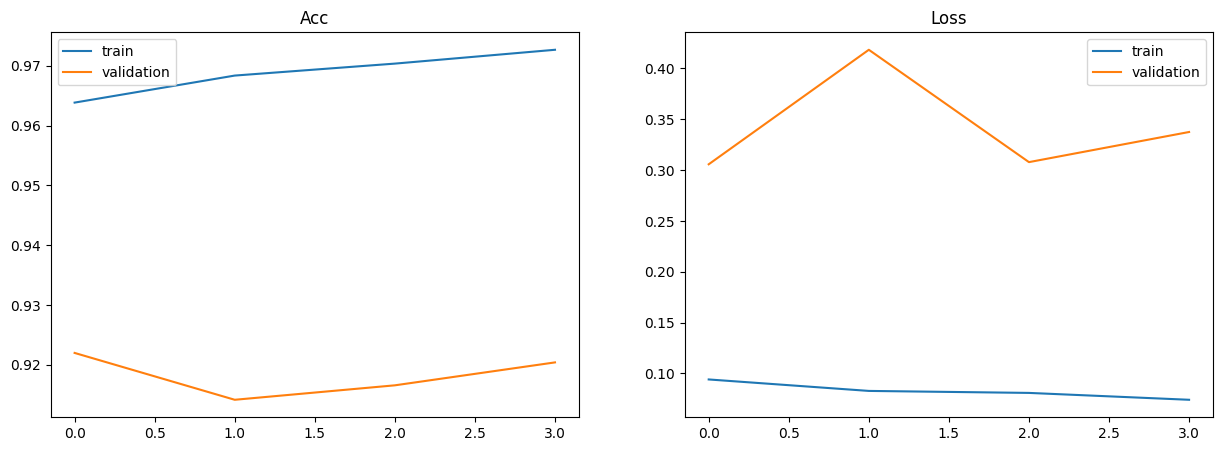

In [44]:
plot_history(history.history)

In [45]:
pred=model4.predict(x_test[0:25])
print(np.round(pred, decimals=3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 691ms/step
[[0.    0.    0.    0.    0.    0.    0.    0.    0.    1.   ]
 [0.    0.    1.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.004 0.    0.    0.    0.    0.    0.996 0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.001 0.    0.999 0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    1.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    1.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    1.    0.    0.   ]
 [0.    0.    0.    0.    1.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    1.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    1.    0.    0.   ]
 [0.    0.    0.    1.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    1.    0.    0.    0.    0.    0.   ]
 [0.    1.    0.

In [47]:
np.argmax(pred, axis=1) #각 샘플에 대해 가장 높은 확률을 가진 클래스의 인덱스를 반환, axis=1은 각 행(샘플)에서 최대값을 찾도록 지정

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 7, 3, 4, 1, 2, 6, 8, 0, 2, 5,
       7, 9, 1])

In [48]:
print(y_test[0:25])

[9 2 1 1 6 1 4 6 5 7 4 5 7 3 4 1 2 4 8 0 2 5 7 9 1]


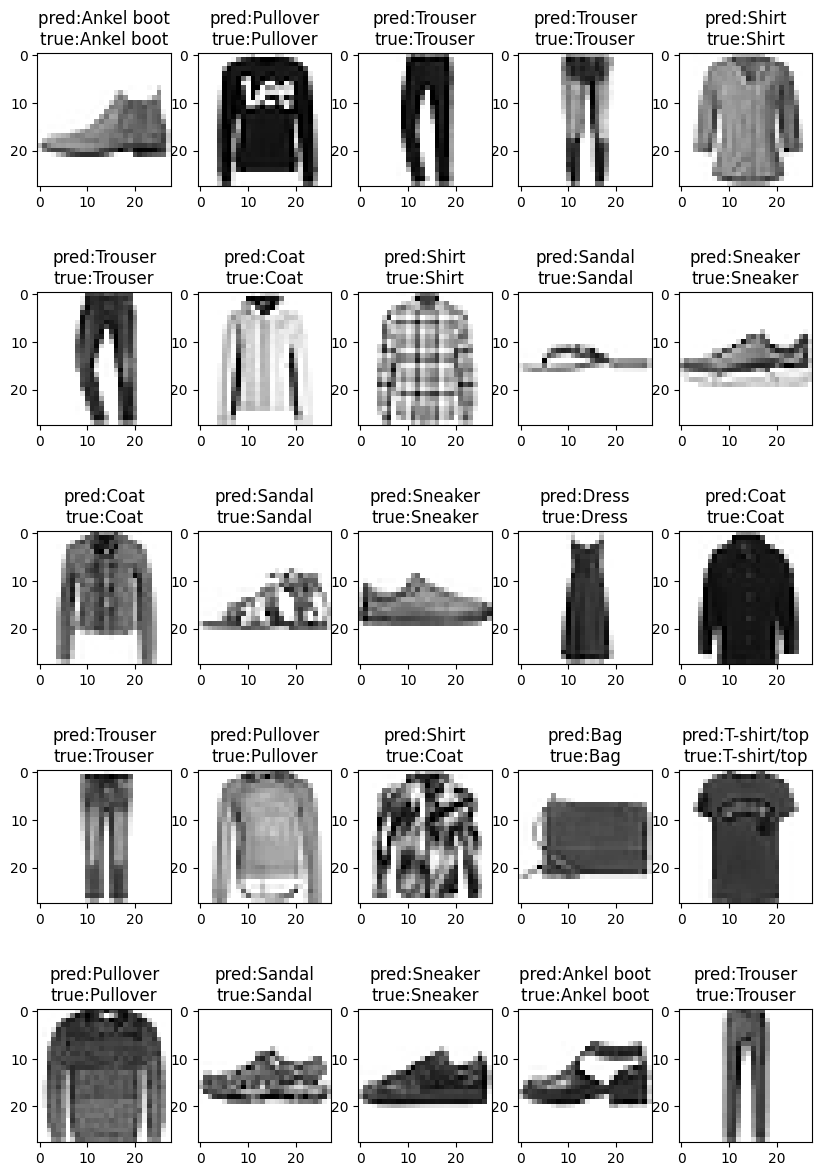

In [ ]:
fig, axs = plt.subplots(5, 5, figsize=(10,15)) #5행 5열의 서브플롯 생성, figsize=(10,15)은 전체 그림의 크기를 가로 10인치, 세로 15인치로 설정
for i in range(5):
    for j in range(5):
        axs[i, j].set_title('pred:{}\ntrue:{}'.format(items[np.argmax(pred[i*5+j])], items[y_test[i*5+j]])) #각 서브플롯의 제목을 설정, pred[i*5+j]는 예측된 클래스 확률 벡터에서 가장 높은 확률을 가진 클래스의 인덱스를 찾고, items 딕셔너리를 사용하여 해당 클래스 이름을 가져옴, y_test[i*5+j]는 실제 클래스 레이블에서 해당 인덱스의 값을 가져와 items 딕셔너리를 사용하여 클래스 이름으로 변환
        axs[i, j].imshow(x_test2d[i*5+j], cmap='gray_r')

## CNN의 시각화

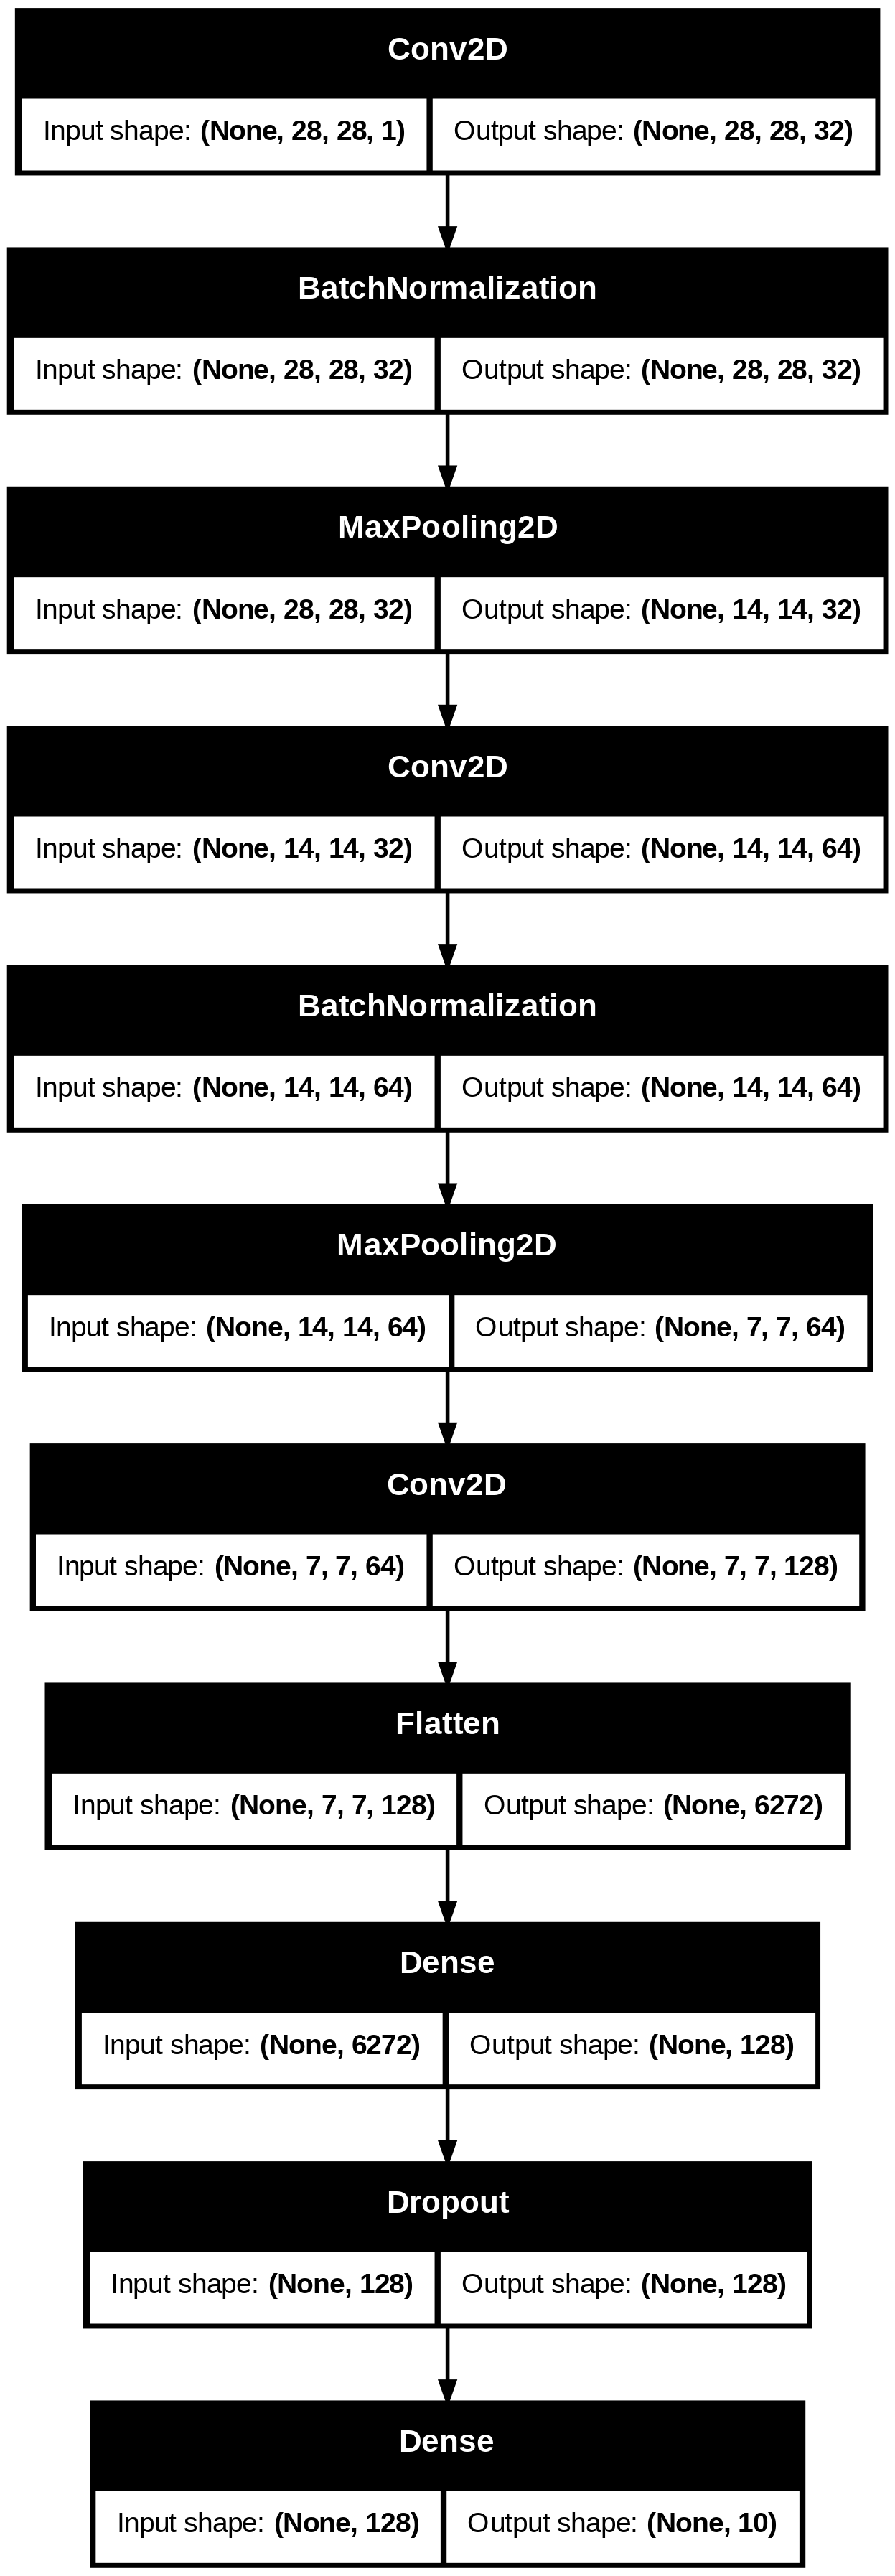

In [50]:
utils.plot_model(model4, show_shapes=True,to_file='fmnist.png') #모델의 구조를 시각적으로 표현하는 함수, model4의 구조를 보여주고, show_shapes=True는 각 레이어의 출력 형태를 함께 표시하도록 설정

### 학습된 Conv층 가져오기

In [51]:
model4.layers

[<Conv2D name=conv2d_9, built=True>,
 <BatchNormalization name=batch_normalization_4, built=True>,
 <MaxPooling2D name=max_pooling2d_6, built=True>,
 <Conv2D name=conv2d_10, built=True>,
 <BatchNormalization name=batch_normalization_5, built=True>,
 <MaxPooling2D name=max_pooling2d_7, built=True>,
 <Conv2D name=conv2d_11, built=True>,
 <Flatten name=flatten_3, built=True>,
 <Dense name=dense_6, built=True>,
 <Dropout name=dropout_3, built=True>,
 <Dense name=dense_7, built=True>]

In [52]:
conv = model4.layers[0] #model4의 첫 번째 레이어(Conv2D 레이어)를 conv 변수에 할당
print(conv.weights[0].shape,conv.weights[1].shape) #Conv2D 레이어의 커널(필터) 가중치의 형태를 출력, (3, 3, 1, 32)는 커널의 높이와 너비가 3x3, 입력 채널 수가 1, 출력 채널 수가 32임을 나타냄

(3, 3, 1, 32) (32,)


In [54]:
weights = conv.weights[0].numpy() #Conv2D 레이어의 커널 가중치를 NumPy 배열로 변환하여 weights 변수에 할당
print(weights.shape) #(3, 3, 1, 32)는 커널의 높이와 너비가 3x3, 입력 채널 수가 1, 출력 채널 수가 32임을 나타냄 
print(weights) 

(3, 3, 1, 32)
[[[[-0.01387286 -0.04807684 -0.30748627  0.04522812 -0.18019405
    -0.34863284 -0.15394853 -0.1724033  -0.03454244  0.10832316
     0.26945502 -0.8157113  -0.07740967  0.06835266  0.01213848
    -0.29531488  0.04326557  0.07624955 -0.11872849 -0.1854068
    -0.00577968 -0.20821054  0.15849625 -0.06291118  0.03431142
    -0.110714   -0.1281621  -0.08017859  0.16752242  0.13446786
    -0.30717435  0.03803636]]

  [[ 0.13859898  0.36202532 -0.85466284 -0.08158103  0.13223886
    -0.23785047 -0.0317192   0.07265508  0.0868174   0.1776534
    -0.06222702 -0.21792589 -0.0634548  -0.06207155  0.00425409
     0.20365837 -0.08011553 -0.40502244  0.21970902  0.17568125
     0.16827077 -0.19050741 -0.04384065  0.15563217  0.17868829
    -0.07916157 -0.02271907 -0.53207153 -0.048593    0.17296322
    -0.18383537 -0.10593167]]

  [[-0.09479725 -0.19411469 -0.5327144   0.04958389  0.07481641
     0.3518927   0.20321034 -0.26854223 -0.14978687 -0.25622377
    -0.13253361 -0.04033676  0

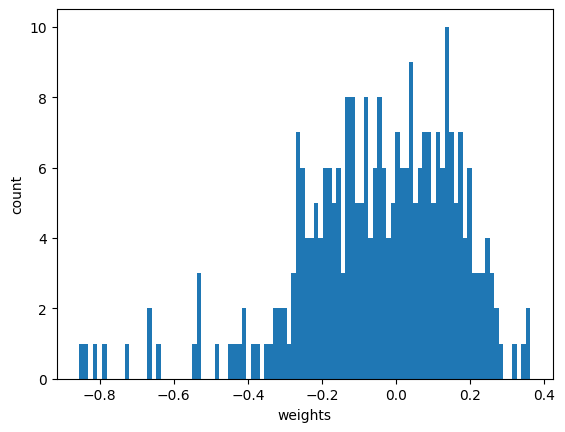

In [55]:
plt.hist(weights.flatten(), bins=100) #커널 가중치의 분포를 히스토그램으로 시각화, weights.flatten()은 다차원 배열을 1차원으로 변환하여 모든 가중치를 하나의 배열로 만듦, bins=100은 히스토그램의 막대 개수를 100개로 설정
plt.xlabel('weights')
plt.ylabel('count')
plt.show()

In [56]:
weights[:,:,0,0] #첫 번째 커널의 가중치 행렬을 출력, weights[:,:,0,0]은 첫 번째 커널의 3x3 가중치 행렬을 나타냄

array([[-0.01387286,  0.13859898, -0.09479725],
       [ 0.22100934,  0.26369825, -0.16594419],
       [ 0.05308755, -0.01027802,  0.01420303]], dtype=float32)

In [57]:
weights[:,:,0,1] #두 번째 커널의 가중치 행렬을 출력, weights[:,:,0,1]은 두 번째 커널의 3x3 가중치 행렬을 나타냄 , 커널 = 필터

array([[-0.04807684,  0.36202532, -0.19411469],
       [ 0.08692235, -0.03364439, -0.6440855 ],
       [ 0.05119304, -0.19127676, -0.66316676]], dtype=float32)

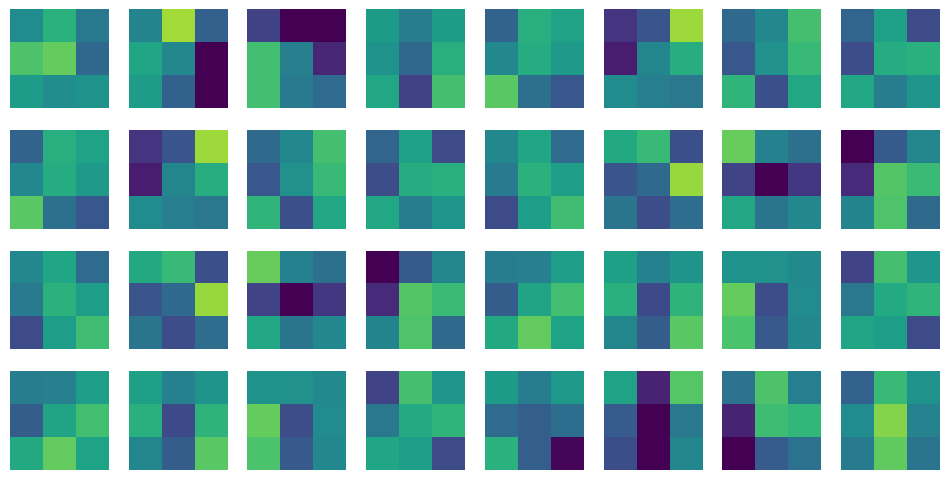

In [61]:
fig, axs = plt.subplots(4,8, figsize=(12,6))
for i in range(4):
    for j in range(8):
        axs[i, j].imshow(weights[:,:,0,i*4+j], vmin=-0.5, vmax=0.5) #각 커널의 가중치 행렬을 이미지로 시각화, weights[:,:,0,i*4+j]는 i*4+j 번째 커널의 3x3 가중치 행렬을 나타냄, vmin=-0.5와 vmax=0.5는 색상 맵의 범위를 설정하여 가중치 값이 -0.5에서 0.5 사이에 있도록 함 
        axs[i, j].axis('off') #각 서브플롯의 축을 숨김, axis('off')는 x축과 y축의 눈금과 레이블을 모두 제거하여 이미지에만 집중할 수 있도록 함
plt.show()

In [62]:
init_model =keras.Sequential() #새로운 Sequential 모델을 생성하여 init_model 변수에 할당, 이 모델은 초기화된 상태로 레이어가 추가되지 않은 빈 모델임
init_model.add(layers.Conv2D(32, (3,3), padding='same',activation='relu', input_shape=(28,28,1))) #Conv2D 레이어 추가, 32개의 필터와 3x3 커널 크기를 사용하여 입력 이미지에서 특징을 추출, padding='same'은 출력 크기가 입력과 동일하도록 패딩을 추가, activation='relu'는 활성화 함수로 ReLU를 사용하여 비선형성을 도입
init_model.summary() #모델의 구조와 각 레이어의 출력 형태를 요약하여 출력, Conv2D 레이어의 가중치가 초기화된 상태로 생성됨

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320 (1.25 KB)

 Trainable params: 320 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
new_conv=init_model.layers[0] #init_model의 첫 번째 레이어(Conv2D 레이어)를 new_conv 변수에 할당, 이 레이어는 초기화된 상태로 가중치가 설정되어 있음
print(new_conv.weights[0].shape, new_conv.weights[1].shape) #Conv2D 레이어의 커널 가중치와 편향의 형태를 출력, (3, 3, 1, 32)는 커널의 높이와 너비가 3x3, 입력 채널 수가 1, 출력 채널 수가 32임을 나타냄, 편향은 각 필터에 대해 하나씩 존재하므로 (32,) 형태임

(3, 3, 1, 32) (32,)


In [64]:
new_weights = init_model.layers[0].weights[0].numpy() #초기화된 Conv2D 레이어의 커널 가중치를 NumPy 배열로 변환하여 new_weights 변수에 할당
print(new_weights.shape) #(3, 3, 1, 32)는 커널의 높이와 너비가 3x3, 입력 채널 수가 1, 출력 채널 수가 32임을 나타냄 
print(new_weights)

(3, 3, 1, 32)
[[[[-0.03087113  0.11343496 -0.11144313  0.09606171 -0.09307508
    -0.0113038  -0.01799696  0.10556579  0.13365291 -0.07394923
    -0.03608053  0.00091082  0.05704933 -0.03120817 -0.07399142
    -0.0007039   0.11733331 -0.10770509  0.00279716 -0.04718456
     0.0624069  -0.1222003  -0.07186296 -0.05998334  0.03242575
     0.06835054  0.02983455 -0.05539076  0.02067891 -0.0713746
    -0.099599    0.04524635]]

  [[-0.01679493  0.05814552 -0.08560804 -0.05012581 -0.1337183
     0.14164834 -0.07778623  0.08820367 -0.0045812  -0.06145538
     0.09560819 -0.04398005  0.04427521 -0.11017039  0.10521725
    -0.05443215  0.05887933 -0.10045672 -0.11288579  0.02156851
     0.00866736  0.05872191  0.00084674 -0.12191212  0.10972716
    -0.03219637  0.11368392  0.09630187  0.1285028   0.1262634
    -0.0938755   0.07087985]]

  [[ 0.12439765 -0.0784741  -0.08647721 -0.01271254 -0.08092152
    -0.13528427 -0.0726708   0.1018196  -0.03969882 -0.11245392
    -0.08442879  0.06531169 -0.

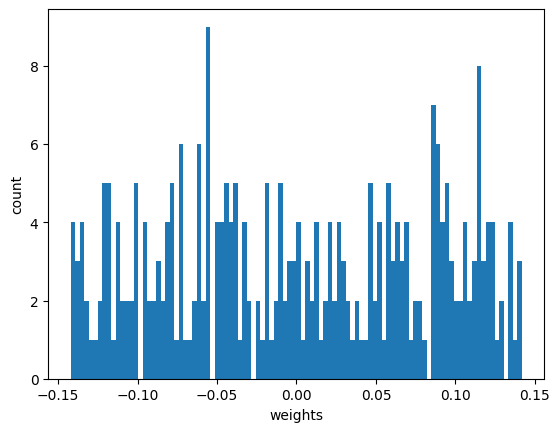

In [65]:
plt.hist(new_weights.flatten(), bins=100) #초기화된 커널 가중치의 분포를 히스토그램으로 시각화, new_weights.flatten()은 다차원 배열을 1차원으로 변환하여 모든 가중치를 하나의 배열로 만듦, bins=100은 히스토그램의 막대 개수를 100개로 설정
plt.xlabel('weights')
plt.ylabel('count')
plt.show()

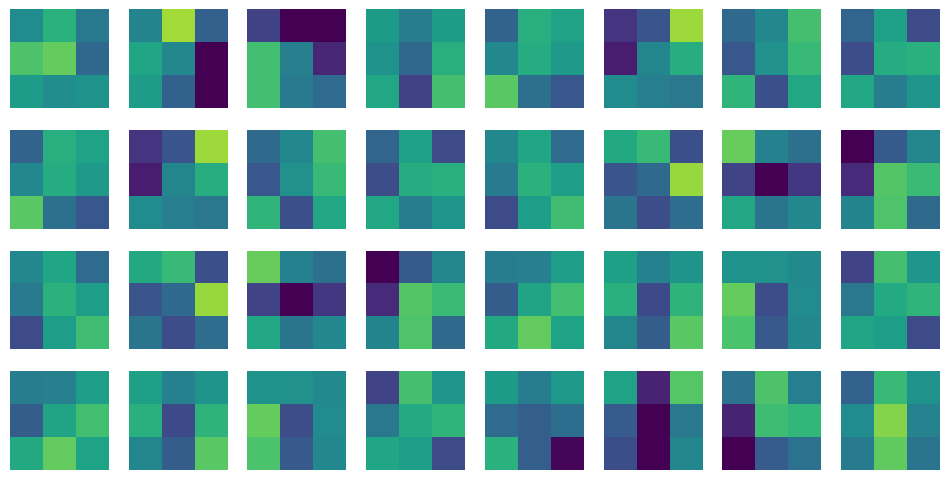

In [66]:
fig,axs = plt.subplots(4,8, figsize=(12,6))
for i in range(4):
    for j in range(8):
        axs[i, j].imshow(weights[:,:,0,i*4+j], vmin=-0.5, vmax=0.5) #각 커널의 가중치 행렬을 이미지로 시각화, weights[:,:,0,i*4+j]는 i*4+j 번째 커널의 3x3 가중치 행렬을 나타냄, vmin=-0.5와 vmax=0.5는 색상 맵의 범위를 설정하여 가중치 값이 -0.5에서 0.5 사이에 있도록 함 
        axs[i, j].axis('off') #각 서브플롯의 축을 숨김, axis('off')는 x축과 y축의 눈금과 레이블을 모두 제거하여 이미지에만 집중할 수 있도록 함
plt.show()

### 필터를 거친 이미지 확인하기

In [67]:
conv1=keras.Model(model4.inputs[0],model4.layers[0].output) #model4의 입력과 첫 번째 레이어의 출력을 사용하여 새로운 모델 conv1을 생성, 이 모델은 model4의 첫 번째 레이어의 출력만을 반환하도록 구성됨
conv1.summary() #conv1 모델의 구조와 각 레이어의 출력 형태를 요약하여 출력, conv1 모델은 model4의 첫 번째 레이어의 출력만을 포함하므로 Conv2D 레이어의 출력 형태가 나타남

Model: "functional_43"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320 (1.25 KB)

 Trainable params: 320 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

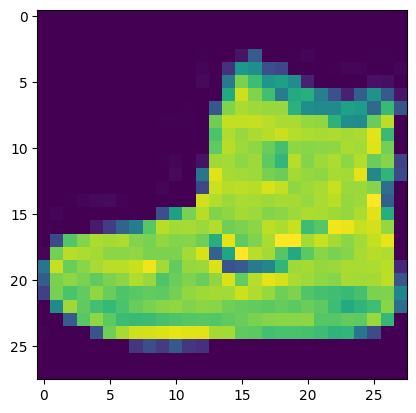

In [ ]:
plt.imshow(x_train2d[0]) #x_train2d의 첫 번째 샘플을 이미지로 시각화, x_train2d[0]은 28x28 크기의 2D 배열로 표현된 첫 번째 훈련 이미지 데이터를 나타냄, plt.imshow()는 이 배열을 이미지로 표시, 기본적으로 픽셀 값이 낮을수록 어둡고 높을수록 밝게 표현됨

In [69]:
feature_map1 = conv1.predict(x_train[0:1]) #conv1 모델을 사용하여 x_train의 첫 번째 샘플에 대한 특징 맵을 예측, x_train[0:1]은 첫 번째 샘플을 배치 형태로 전달하기 위해 슬라이싱한 것, feature_map1은 Conv2D 레이어의 출력인 특징 맵을 포함하는 배열이 됨

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step


In [70]:
print(feature_map1.shape) #특징 맵의 형태를 출력, (1, 28, 28, 32)는 배치 크기가 1, 특징 맵의 높이와 너비가 28x28, 채널 수가 32임을 나타냄

(1, 28, 28, 32)


In [73]:
feature_map1[0,:,:,2] #첫 번째 샘플의 첫 번째 채널에 해당하는 특징 맵을 출력, feature_map1[0,:,:,0]은 첫 번째 샘플의 28x28 크기의 첫 번째 채널에 해당하는 특징 맵을 나타냄

array([[0.0209034 , 0.0209034 , 0.0209034 , 0.0209034 , 0.0209034 ,
        0.0209034 , 0.0209034 , 0.0209034 , 0.0209034 , 0.0209034 ,
        0.0209034 , 0.0209034 , 0.0209034 , 0.0209034 , 0.0209034 ,
        0.0209034 , 0.0209034 , 0.0209034 , 0.0209034 , 0.0209034 ,
        0.0209034 , 0.0209034 , 0.0209034 , 0.0209034 , 0.0209034 ,
        0.0209034 , 0.0209034 , 0.0209034 ],
       [0.0209034 , 0.0209034 , 0.0209034 , 0.0209034 , 0.0209034 ,
        0.0209034 , 0.0209034 , 0.0209034 , 0.0209034 , 0.0209034 ,
        0.0209034 , 0.0209034 , 0.0209034 , 0.0209034 , 0.0209034 ,
        0.0209034 , 0.0209034 , 0.0209034 , 0.0209034 , 0.0209034 ,
        0.0209034 , 0.0209034 , 0.0209034 , 0.0209034 , 0.0209034 ,
        0.0209034 , 0.0209034 , 0.0209034 ],
       [0.0209034 , 0.0209034 , 0.0209034 , 0.0209034 , 0.0209034 ,
        0.0209034 , 0.0209034 , 0.0209034 , 0.0209034 , 0.0209034 ,
        0.0209034 , 0.02031916, 0.02056619, 0.02168711, 0.01330822,
        0.        , 0.0064

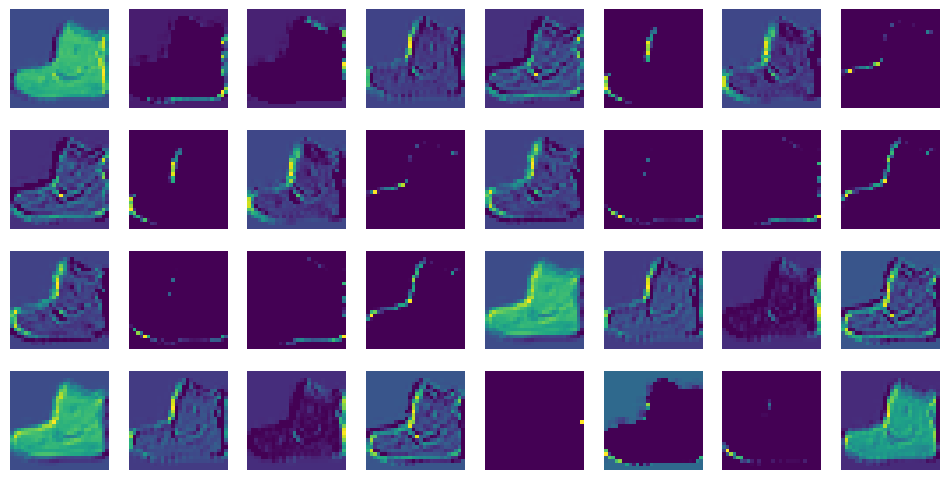

In [76]:
fig,axs = plt.subplots(4,8, figsize=(12,6))
for i in range(4):
    for j in range(8):
        axs[i, j].imshow(feature_map1[0,:,:,i*4+j]) #각 커널의 가중치 행렬을 이미지로 시각화, weights[:,:,0,i*4+j]는 i*4+j 번째 커널의 3x3 가중치 행렬을 나타냄, vmin=-0.5와 vmax=0.5는 색상 맵의 범위를 설정하여 가중치 값이 -0.5에서 0.5 사이에 있도록 함 
        axs[i, j].axis('off') #각 서브플롯의 축을 숨김, axis('off')는 x축과 y축의 눈금과 레이블을 모두 제거하여 이미지에만 집중할 수 있도록 함
plt.show()

In [77]:
model4.layers

[<Conv2D name=conv2d_9, built=True>,
 <BatchNormalization name=batch_normalization_4, built=True>,
 <MaxPooling2D name=max_pooling2d_6, built=True>,
 <Conv2D name=conv2d_10, built=True>,
 <BatchNormalization name=batch_normalization_5, built=True>,
 <MaxPooling2D name=max_pooling2d_7, built=True>,
 <Conv2D name=conv2d_11, built=True>,
 <Flatten name=flatten_3, built=True>,
 <Dense name=dense_6, built=True>,
 <Dropout name=dropout_3, built=True>,
 <Dense name=dense_7, built=True>]

In [79]:
con2=keras.Model(model4.inputs[0],model4.layers[3].output)
con2.summary()

Model: "functional_45"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,944 (74.00 KB)

 Trainable params: 18,880 (73.75 KB)

 Non-trainable params: 64 (256.00 B)

In [80]:
feature_map2 = con2.predict(x_train[0:1])
print(feature_map2.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step
(1, 14, 14, 64)


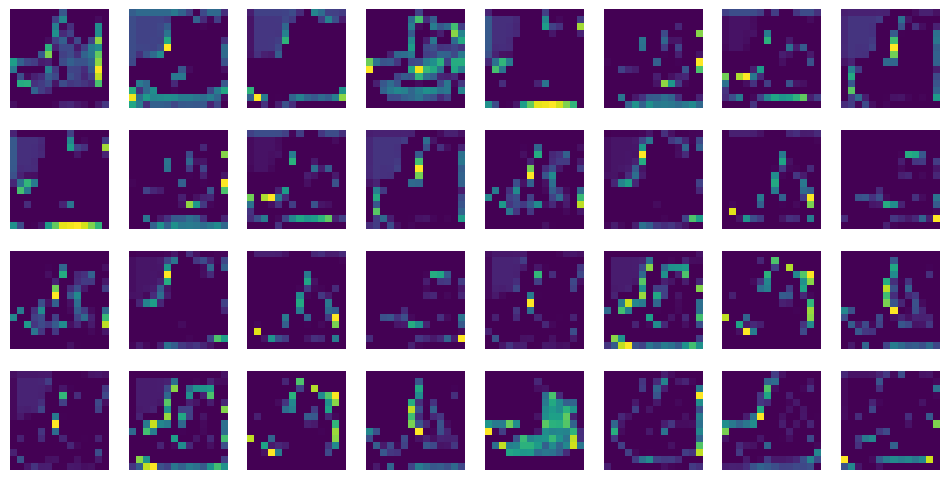

In [81]:
fig,axs = plt.subplots(4,8, figsize=(12,6))
for i in range(4):
    for j in range(8):
        axs[i, j].imshow(feature_map2[0,:,:,i*4+j]) #각 커널의 가중치 행렬을 이미지로 시각화, weights[:,:,0,i*4+j]는 i*4+j 번째 커널의 3x3 가중치 행렬을 나타냄, vmin=-0.5와 vmax=0.5는 색상 맵의 범위를 설정하여 가중치 값이 -0.5에서 0.5 사이에 있도록 함 
        axs[i, j].axis('off') #각 서브플롯의 축을 숨김, axis('off')는 x축과 y축의 눈금과 레이블을 모두 제거하여 이미지에만 집중할 수 있도록 함
plt.show()


In [82]:
model4.layers

[<Conv2D name=conv2d_9, built=True>,
 <BatchNormalization name=batch_normalization_4, built=True>,
 <MaxPooling2D name=max_pooling2d_6, built=True>,
 <Conv2D name=conv2d_10, built=True>,
 <BatchNormalization name=batch_normalization_5, built=True>,
 <MaxPooling2D name=max_pooling2d_7, built=True>,
 <Conv2D name=conv2d_11, built=True>,
 <Flatten name=flatten_3, built=True>,
 <Dense name=dense_6, built=True>,
 <Dropout name=dropout_3, built=True>,
 <Dense name=dense_7, built=True>]

In [83]:
con3=keras.Model(model4.inputs[0],model4.layers[6].output)
con3.summary()

Model: "functional_46"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,056 (363.50 KB)

 Trainable params: 92,864 (362.75 KB)

 Non-trainable params: 192 (768.00 B)

In [84]:
feature_map3=con3.predict(x_train[0:1])
print(feature_map3.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step
(1, 7, 7, 128)


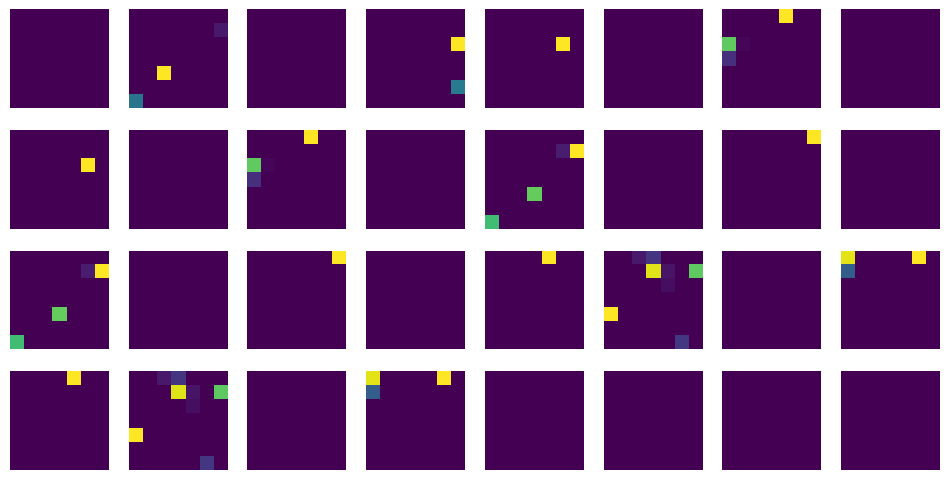

In [85]:
fig, axs = plt.subplots(4, 8, figsize=(12,6))
for i in range(4):
    for j in range(8):
        axs[i, j].imshow(feature_map3[0,:,:,i*4+j]) #각 커널의 가중치 행렬을 이미지로 시각화, weights[:,:,0,i*4+j]는 i*4+j 번째 커널의 3x3 가중치 행렬을 나타냄, vmin=-0.5와 vmax=0.5는 색상 맵의 범위를 설정하여 가중치 값이 -0.5에서 0.5 사이에 있도록 함
        axs[i, j].axis('off') #각 서브플롯의 축을 숨김, axis('off')는 x축과 y축의 눈금과 레이블을 모두 제거하여 이미지에만 집중할 수 있도록 함
plt.show()